# Storage Benchmark: Database Engines

**Docker image**: `benchmark`

> **Docker required**: This notebook depends on the `benchmark` environment and
> database services. Run with:
> ```bash
> docker compose --profile benchmark up -d timescaledb clickhouse questdb influxdb
> docker compose --profile benchmark run --rm benchmark python 02_financial_data_universe/21_storage_benchmark_database.py
> ```

**Focus**: Query-capable databases for financial time-series

## Database Categories

| Category | Examples | Characteristics |
|----------|----------|-----------------|
| **Embedded** | SQLite, DuckDB, ArcticDB | In-process, no server required |
| **Time-Series Servers** | ClickHouse, QuestDB, TimescaleDB | Production-scale, Docker required |
| **General Purpose** | PostgreSQL, InfluxDB | Baseline comparisons |
| **HFT Specialized** | kdb+/PyKX | Industry standard for trading |

## Operations Benchmarked

1. **Write** - Bulk insert performance
2. **Read** - Full table scan
3. **Range Query** - 7-day time window (backtesting workflow)
4. **OHLCV Aggregation** - Resample minute bars to daily bars
5. **ASOF Join** - Trade-quote alignment (critical for microstructure)

## Timing Policy

One policy, applied identically to every engine. Engines that were timed
under different rules would not belong on the same chart, so the rules are
stated here and enforced by the `time_write` / `time_read` helpers rather
than by per-call arguments:

- **Writes** (`time_write`) - a single shot, no warm-up, against a table
  created fresh for the run. Bulk load happens once per dataset, so that is
  what we time. Repeating it would append duplicate rows on the append-only
  engines, or require a teardown that is not part of the write.
- **A write bar is what the client pays, and the clients differ.** SQLite,
  DuckDB, ClickHouse and kdb+ take the panel in one block (`to_sql`, a Parquet
  scan, `insert_df`, `set`). PostgreSQL and TimescaleDB have to build one
  Python tuple per row for `execute_values`, and InfluxDB one `Point` per row
  for line protocol. That construction is what using those interfaces costs,
  so it stays inside the timed region, and each of the three also measures it
  on its own and prints the share; the table above the chart collects them.
  Those three numbers are the *explicit* row construction and nothing more.
  Every client converts and serializes somewhere - `to_sql` still prepares and
  binds each row, `insert_df` still serializes the frame - and none of that is
  separable from outside, so a bar without a measured share is not a bar that
  is all engine. Read every write bar as "what it costs to get this panel into
  this engine through its Python client", never as the engine's ingest rate.
- **Durability inside the timed region.** PostgreSQL and TimescaleDB commit
  synchronously, so their flush cost is inside the timed call. QuestDB (ILP
  + WAL) and InfluxDB acknowledge before the rows are queryable, so they
  poll to first-queryable via `wait_until_rows_visible` *inside* the timed
  call. Every write time therefore ends at the same event: the data is
  durable and readable.
- **Reads, aggregations, and joins** (`time_read`) - mean of `TIMING_RUNS`
  runs after one untimed warm-up. **These are warm numbers**, on both the OS
  page cache and each server's buffer pool, and they flatter every engine
  that caches. A client cannot drop a server's cache, so a "cold" read here
  would be cold for the embedded engines and warm for the servers - neither
  cold nor comparable. Warm and uniform is the measurable choice; §2.4 says
  so where it reports these figures.
- **Every read is validated** against the expected row count, exactly. Each
  query below is deterministic and its answer is known before it runs, so a
  near miss is a wrong answer rather than a tolerable one - and a query that
  silently returns a truncated result would otherwise post the fastest time
  on the chart.

## What the size column does and does not mean

Unlike the timings, on-disk size is **not** measured the same way for every
engine, because each engine only exposes its own accounting. Read the size
column as "what this engine reports it is using", not as a like-for-like
compression ratio:

| Engine | Reported by | Counts |
|--------|-------------|--------|
| SQLite / DuckDB | file size on disk | the database file |
| ClickHouse | `system.parts.bytes_on_disk` | **compressed** data parts |
| QuestDB | `table_storage().diskSize` | the table's full on-disk footprint |
| PostgreSQL / TimescaleDB | `pg_total_relation_size` / `hypertable_size` | table **plus indexes** (and, for the hypertable, all its chunks) |
| InfluxDB | *not exposed* | client API reports no per-bucket size, so it is left empty rather than recorded as zero |

Comparing ClickHouse's compressed parts against PostgreSQL's table-plus-index
total is not a compression comparison. The file-format notebook
(`20_storage_benchmark_file`) is where size is measured identically across
contenders and can be compared directly.

## Quick Start

```bash
# Embedded engines only. DuckDB and SQLite need nothing beyond the base install.
uv run python 02_financial_data_universe/21_storage_benchmark_database.py

# With the server engines as well, from the host (compose publishes their ports)
docker compose --profile databases up -d timescaledb postgres clickhouse questdb influxdb
uv run --extra db-benchmark python 02_financial_data_universe/21_storage_benchmark_database.py
```

The `db-benchmark` extra also carries ArcticDB, which publishes no Linux ARM64 wheel
and no source distribution. On ARM64 the install fails before the notebook can run,
so the optional-import guard never gets the chance to skip it: use the Docker path
above, whose `benchmark` image ships the server clients without ArcticDB.

The scale is the `BENCHMARK_SCALE` parameter below, not an environment variable:
the cell after the parameters cell writes the parameter back into the environment
for `utils.storage_benchmarks` to read, so a `BENCHMARK_SCALE=...` prefix on the
command line is overwritten before anything reads it. Change the scale by editing
the parameter, or by injecting it with Papermill as CI does.

Whichever engines answer, the coverage report near the bottom names the ones that
produced the numbers on this page, and the ones that did not.

## Setup

In [1]:
"""Storage Benchmark — Database engine comparison for financial time-series."""

import contextlib
import gc
import json
import os
import shutil
import sqlite3
import subprocess
import time as time_module
import urllib.parse
import urllib.request
from datetime import UTC, timedelta
from pathlib import Path

### Declared parameters

`BENCHMARK_SCALE` selects the panel size; the production setting is the one §2.4
quotes, and CI overrides it to the small scale through Papermill. Every cell that
reports a number also reports the scale that produced it, so a figure lifted off
this page carries its own provenance.

`RANGE_QUERY_SHARE` is the fraction of the panel the range query should select.
It is a share rather than a fixed number of days because the panel's calendar span
grows with the scale: a fixed seven-day window selects a fifth of the large panel
and *all* of the small one, which would silently turn the range-query panel of the
chart into a second copy of the full scan.

`LOG_AXIS_RATIO` is the spread at which a chart panel switches to a logarithmic
x-axis, measured on the bars actually drawn rather than assumed from a past run.

In [2]:
BENCHMARK_SCALE = "L"
RANGE_QUERY_SHARE = 0.2
LOG_AXIS_RATIO = 10.0

`utils.storage_benchmarks` reads the scale from the environment when it is imported,
so the variable has to be set before the import rather than passed to a function
afterwards.

In [3]:
os.environ["BENCHMARK_SCALE"] = BENCHMARK_SCALE

import pandas as pd
import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from utils.paths import display_path, get_output_dir
from utils.storage_benchmarks import (
    ACTIVE_SCALE,
    BENCHMARK_DIR,
    DB_CONFIG,
    N_ROWS_PER_SYMBOL,
    N_SYMBOLS,
    N_TICKS_QUOTES,
    N_TICKS_TRADES,
    TIMING_RUNS,
    WAL_FLUSH_TIMEOUT,
    BenchmarkResult,
    estimate_memory_mb,
    force_materialize_pandas,
    force_materialize_polars,
    generate_ohlcv_data,
    generate_tick_data,
    get_scale_config,
    save_benchmark_results,
    save_chart,
    time_read,
    time_write,
    validate_result,
    wait_until_rows_visible,
)
from utils.style import COLORS, show_plotly_with_alt

In [4]:
OUTPUT_DIR = get_output_dir(2, "storage_benchmark")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Check Available Databases

In [5]:
benchmark_status = {
    # Embedded (always available if package installed)
    "SQLite": {"expected": True, "tested": False, "category": "embedded"},
    # DuckDB is imported unconditionally below, so its absence raises rather than
    # lowering the bar this run is measured against.
    "DuckDB": {"expected": True, "tested": False, "category": "embedded"},
    "ArcticDB": {"expected": False, "tested": False, "category": "embedded"},
    # Servers (need Docker)
    "ClickHouse": {"expected": True, "tested": False, "category": "server"},
    "QuestDB": {"expected": True, "tested": False, "category": "server"},
    "TimescaleDB": {"expected": True, "tested": False, "category": "server"},
    "InfluxDB": {"expected": True, "tested": False, "category": "server"},
    "PostgreSQL": {"expected": True, "tested": False, "category": "server"},
    "kdb+/PyKX": {"expected": False, "tested": False, "category": "hft"},
}

print("=" * 70)
print(f"DATABASE BENCHMARK - Scale: {ACTIVE_SCALE}")
print("=" * 70)

DATABASE BENCHMARK - Scale: L


### Which engines are present

DuckDB ships in both the `benchmark` (ARM64) and `benchmark-full` (x86) images, and
SQLite comes with Python, so both are always available and the notebook refuses to
continue without DuckDB rather than quietly dropping it. ArcticDB is x86-only and
lives in `benchmark-full`; where it is absent it is reported as absent.

In [6]:
try:
    import duckdb  # noqa: F401
except ImportError as exc:
    raise ImportError(
        "DuckDB is not available in the current image.\n"
        "This notebook runs in the `benchmark` image:\n"
        "  docker compose --profile benchmark run --rm benchmark \\\n"
        "      python 02_financial_data_universe/21_storage_benchmark_database.py"
    ) from exc

print("\n### Embedded Databases")
print("[OK] DuckDB: Available")
print("[OK] SQLite: Available (built-in)")


### Embedded Databases
[OK] DuckDB: Available
[OK] SQLite: Available (built-in)


The ArcticDB guard below catches `Exception`, not `ImportError`. An ArcticDB that is
installed but cannot run raises something else entirely - `NotImplementedError`
against an unsupported protobuf, for one - and a guard that catches only
`ImportError` lets that end the notebook. An optional engine has to be optional in
every way it can fail to be usable, not only in the one way it can be absent.

In [7]:
try:
    import arcticdb as adb

    HAS_ARCTICDB = True
    benchmark_status["ArcticDB"]["expected"] = True
    print("[OK] ArcticDB: Available")
except Exception as exc:
    HAS_ARCTICDB = False
    print(f"○ ArcticDB: unavailable, skipping ({type(exc).__name__}: {exc})")

○ ArcticDB: unavailable, skipping (NotImplementedError: We only support protobuf versions 3, 4, 5 & 6. You have 7.35.0)


In [8]:
# === Check Server Databases ===
print("\n### Server Databases (Docker required)")

# ClickHouse
try:
    import clickhouse_connect

    ch_client = clickhouse_connect.get_client(
        host=DB_CONFIG["clickhouse"]["host"], port=DB_CONFIG["clickhouse"]["port"]
    )
    ch_client.query("SELECT 1")
    HAS_CLICKHOUSE = True
    print("[OK] ClickHouse: Available")
except Exception:
    HAS_CLICKHOUSE = False
    print("[FAIL] ClickHouse: Not available (start Docker)")

# QuestDB
try:
    urllib.request.urlopen(
        f"http://{DB_CONFIG['questdb']['host']}:{DB_CONFIG['questdb']['http_port']}/exec?query=SELECT%201",
        timeout=2,
    )
    HAS_QUESTDB = True
    print("[OK] QuestDB: Available")
except Exception:
    HAS_QUESTDB = False
    print("[FAIL] QuestDB: Not available (start Docker)")


### Server Databases (Docker required)


[OK] ClickHouse: Available
[OK] QuestDB: Available


In [9]:
# Check TimescaleDB and InfluxDB availability
try:
    import psycopg2

    ts_conn = psycopg2.connect(
        host=DB_CONFIG["timescaledb"]["host"],
        port=DB_CONFIG["timescaledb"]["port"],
        user=DB_CONFIG["timescaledb"]["user"],
        password=DB_CONFIG["timescaledb"]["password"],
        database=DB_CONFIG["timescaledb"]["database"],
        connect_timeout=2,
    )
    ts_conn.close()
    HAS_TIMESCALEDB = True
    print("[OK] TimescaleDB: Available")
except Exception:
    HAS_TIMESCALEDB = False
    print("[FAIL] TimescaleDB: Not available (start Docker)")

# InfluxDB
try:
    from influxdb_client import InfluxDBClient

    influx_test = InfluxDBClient(
        url=f"http://{DB_CONFIG['influxdb']['host']}:{DB_CONFIG['influxdb']['port']}",
        token=DB_CONFIG["influxdb"]["token"],
        org=DB_CONFIG["influxdb"]["org"],
        timeout=2000,
    )
    HAS_INFLUXDB = bool(influx_test.ready())
    influx_test.close()
    del influx_test
    if HAS_INFLUXDB:
        print("[OK] InfluxDB: Available")
    else:
        print("[FAIL] InfluxDB: Not ready")
except Exception:
    HAS_INFLUXDB = False
    print("[FAIL] InfluxDB: Not available (start Docker)")

[OK] TimescaleDB: Available


[OK] InfluxDB: Available


In [10]:
# PostgreSQL (vanilla, separate from TimescaleDB)
try:
    import psycopg2

    pg_conn_check = psycopg2.connect(
        host=DB_CONFIG["postgres"]["host"],
        port=DB_CONFIG["postgres"]["port"],
        user=DB_CONFIG["postgres"]["user"],
        password=DB_CONFIG["postgres"]["password"],
        database=DB_CONFIG["postgres"]["database"],
        connect_timeout=2,
    )
    pg_conn_check.close()
    HAS_POSTGRES = True
    print("[OK] PostgreSQL: Available")
except Exception:
    HAS_POSTGRES = False
    print("[FAIL] PostgreSQL: Not available (start Docker)")

[OK] PostgreSQL: Available


### kdb+ via PyKX, in IPC mode

The q binary and the licence are looked for *before* PyKX is imported, and the
order is load-bearing. PyKX must never be imported in unlicensed mode
(`PYKX_UNLICENSED=1`). An unlicensed import leaves the process in a state where
later numpy work segfaults, and the crash lands in `generate_ohlcv_data`, nowhere
near the import that caused it, so it reads as a data bug. Without a licence there
is nothing to benchmark, so PyKX is not imported at all and kdb+ is skipped.

In [11]:
HAS_PYKX = False
Q_BINARY: Path | None = None

# Check multiple locations for q binary (host install or Docker mount)
Q_BINARY_LOCATIONS = [
    Path.home() / ".kx" / "bin" / "q",  # Standard location
    Path("/opt/kx/bin/q"),  # Alternative system location
]
KX_LICENSE_DIRS = [Path.home() / ".pykx", Path.home() / ".kx"]

for q_path in Q_BINARY_LOCATIONS:
    if q_path.exists() and q_path.is_file():
        Q_BINARY = q_path
        break

KX_LICENSE_FILE = next(
    (d / f for d in KX_LICENSE_DIRS for f in ("kc.lic", "k4.lic") if (d / f).exists()), None
)

if Q_BINARY is None or KX_LICENSE_FILE is None:
    print("○ PyKX/kdb+: Optional (not configured) — skipping, no result will be claimed")
    if Q_BINARY is None:
        print("    → Get a free personal edition: https://kx.com/kdb-personal-edition-download/")
        print(f"    → Install the q binary to: {display_path(Q_BINARY_LOCATIONS[0])}")
    if KX_LICENSE_FILE is None:
        print(f"    → Place the licence file (kc.lic) in: {display_path(KX_LICENSE_DIRS[0])}")
else:
    try:
        # q resolves its licence from QLIC, not from the file merely existing on
        # disk: without this the q process starts and dies "no license loaded".
        os.environ["QLIC"] = str(KX_LICENSE_FILE.parent)
        import pykx as kx

        HAS_PYKX = True
        benchmark_status["kdb+/PyKX"]["expected"] = True
        print(
            f"[OK] PyKX/kdb+ {kx.__version__}: Available "
            f"(IPC mode, licence {display_path(KX_LICENSE_FILE)})"
        )
    except Exception as exc:
        # As with ArcticDB: an optional engine that is present but unusable must not
        # end the run, whatever it raises on the way out.
        print(f"○ PyKX/kdb+: unavailable, skipping ({type(exc).__name__}: {exc})")

○ PyKX/kdb+: unavailable, skipping (ModuleNotFoundError: No module named 'pykx')


`expected` marks an engine as one the chapter compares. `available` says it answered
the availability check on this machine. They are different questions, and conflating
them turns a laptop with no Docker running into a run that reports five failures.
The three counts below, and the coverage report at the end, are read off the status
table rather than written as literals, so adding an engine to that table is most of
what adding an engine takes.

In [12]:
AVAILABILITY = {
    "SQLite": True,
    "DuckDB": True,
    "ArcticDB": HAS_ARCTICDB,
    "ClickHouse": HAS_CLICKHOUSE,
    "QuestDB": HAS_QUESTDB,
    "TimescaleDB": HAS_TIMESCALEDB,
    "InfluxDB": HAS_INFLUXDB,
    "PostgreSQL": HAS_POSTGRES,
    "kdb+/PyKX": HAS_PYKX,
}
assert set(AVAILABILITY) == set(benchmark_status), (
    "every engine in the status table needs an availability flag"
)
for _engine, _is_available in AVAILABILITY.items():
    benchmark_status[_engine]["available"] = _is_available

n_embedded = sum(v["available"] for v in benchmark_status.values() if v["category"] == "embedded")
n_servers = sum(v["available"] for v in benchmark_status.values() if v["category"] == "server")
n_hft = sum(v["available"] for v in benchmark_status.values() if v["category"] == "hft")

print(f"\n[OK] {n_embedded} embedded + {n_servers} server + {n_hft} HFT database(s) available")

if n_servers == 0:
    print("\n[WARN]  No server databases. Start Docker containers:")
    print(
        "   docker compose --profile benchmark up -d timescaledb clickhouse questdb influxdb postgres"
    )


[OK] 2 embedded + 5 server + 0 HFT database(s) available


## Generate Test Data

In [13]:
scale_cfg = get_scale_config(ACTIVE_SCALE)
print(f"\nTarget: {scale_cfg['target_memory']} in-memory")
print(f"OHLCV: {N_SYMBOLS} symbols × {N_ROWS_PER_SYMBOL:,} rows/symbol")
print(f"Tick: {N_TICKS_TRADES:,} trades, {N_TICKS_QUOTES:,} quotes")

print("\n=== Generating synthetic data ===\n")

# Generate OHLCV data
ohlcv_df = generate_ohlcv_data(n_symbols=N_SYMBOLS, n_rows=N_ROWS_PER_SYMBOL)
total_rows = len(ohlcv_df)
memory_mb = estimate_memory_mb(ohlcv_df)
print(f"OHLCV data: {total_rows:,} rows ({memory_mb:.2f} MB)")

# Generate tick data for ASOF joins
trades_df, quotes_df = generate_tick_data(
    n_trades=N_TICKS_TRADES, n_quotes=N_TICKS_QUOTES, n_symbols=N_SYMBOLS
)
print(f"Tick data: {len(trades_df):,} trades, {len(quotes_df):,} quotes")

# pandas versions (some tools require pandas)
ohlcv_pandas = ohlcv_df.to_pandas()
trades_pandas = trades_df.to_pandas()
quotes_pandas = quotes_df.to_pandas()

# Results collection
results: list[BenchmarkResult] = []


Target: 100MB in-memory
OHLCV: 100 symbols × 10,000 rows/symbol
Tick: 500,000 trades, 2,500,000 quotes

=== Generating synthetic data ===



OHLCV data: 1,000,000 rows (63.90 MB)


Tick data: 500,000 trades, 2,500,000 quotes


### Measuring the row construction that is written out

PostgreSQL, TimescaleDB and InfluxDB reach their servers through interfaces that
take one Python object per row, so building those objects is part of what writing
through them costs and it stays inside the timed write. Because that construction
is a separate expression, it can also be timed on its own, which the helper below
does. What comes back is a lower bound on each of those three clients' share, not
the whole of it: the client still converts and serializes what it is handed, and
so does every client whose interface takes a frame. Nothing here measures that.

In [14]:
client_side_build: dict[str, float] = {}


def measure_row_build(engine: str, build) -> float:
    """Time an engine's client-side row construction in isolation."""
    gc.collect()
    started = time_module.perf_counter()
    rows = build()
    elapsed = time_module.perf_counter() - started
    del rows
    gc.collect()
    client_side_build[engine] = elapsed
    return elapsed


def report_row_build(engine: str, write_seconds: float) -> None:
    """Print an engine's client-side share of its own write time."""
    build_seconds = client_side_build[engine]
    print(
        f"  Client-side row building: {build_seconds:.3f}s of the {write_seconds:.3f}s "
        f"write ({build_seconds / write_seconds:.0%})"
    )

## Benchmark Windows

Two derived quantities that every engine below reuses, so that all engines answer
the *same* question and can be validated against the same expected row count:

- **Range query**: the leading sessions of the panel, the slice a backtest walks.
  The window is sized as a share of the panel rather than as a fixed number of
  calendar days, because the panel's span is a function of the scale. Seven
  calendar days is a fifth of the large panel but covers the small panel entirely,
  and a range query that selects every row is a full scan wearing a different
  name: the chart would show two panels measuring one query and the reader would
  have no way to tell. Sizing by share keeps the question the same at every scale,
  and the cell below prints the share it actually achieved.
- **Aggregation**: minute bars resampled to **daily** bars. Every engine buckets
  by day; bucketing minute data by minute would be a near-identity for the engines
  that did it and a real reduction for the ones that did not, which is not a
  comparison.

In [15]:
session_first_ts = (
    ohlcv_df.group_by(pl.col("timestamp").dt.date().alias("session"))
    .agg(pl.col("timestamp").min().alias("first_ts"))
    .sort("session")["first_ts"]
    .to_list()
)
n_sessions = len(session_first_ts)
range_sessions = max(1, round(RANGE_QUERY_SHARE * n_sessions))

range_start = ohlcv_df["timestamp"].min()
if range_sessions < n_sessions:
    range_end = session_first_ts[range_sessions]
else:
    range_end = ohlcv_df["timestamp"].max() + timedelta(minutes=1)

range_expected_rows = ohlcv_df.filter(
    (pl.col("timestamp") >= range_start) & (pl.col("timestamp") < range_end)
).height
range_share = range_expected_rows / total_rows
agg_expected_rows = ohlcv_df.select(
    pl.struct("symbol", pl.col("timestamp").dt.truncate("1d")).n_unique()
).item()

print(f"Panel spans {n_sessions} trading sessions: {range_start} → {ohlcv_df['timestamp'].max()}")
print(
    f"Range query  : first {range_sessions} of {n_sessions} sessions, "
    f"{range_start} ≤ timestamp < {range_end} "
    f"→ {range_expected_rows:,} rows ({range_share:.1%} of panel)"
)
print(f"Aggregation  : minute bars → {agg_expected_rows:,} daily bars")
if range_sessions >= n_sessions:
    print(
        "  [WARN] The panel is only one window wide at this scale, so the range query "
        "reads every row and its chart panel repeats the full scan."
    )

Panel spans 26 trading sessions: 2024-01-02 09:30:00 → 2024-02-06 13:39:00
Range query  : first 5 of 26 sessions, 2024-01-02 09:30:00 ≤ timestamp < 2024-01-09 09:30:00 → 195,000 rows (19.5% of panel)
Aggregation  : minute bars → 2,600 daily bars


---
# Part 1: Embedded Databases
---

## SQLite (Embedded RDBMS)

SQLite is an embedded relational database:
- ACID compliant, single-file database
- Good for transactional workloads (OLTP)
- Limited analytical query optimization
- No native ASOF join

In [16]:
print("\n" + "=" * 70)
print("SQLITE BENCHMARK")
print("=" * 70)

benchmark_status["SQLite"]["tested"] = True
sqlite_path = BENCHMARK_DIR / f"ohlcv_{ACTIVE_SCALE.lower()}.db"


# Write
def write_sqlite():
    if sqlite_path.exists():
        sqlite_path.unlink()
    with contextlib.closing(sqlite3.connect(sqlite_path)) as conn:
        ohlcv_pandas.to_sql("ohlcv", conn, if_exists="replace", index=False)
        conn.execute("CREATE INDEX IF NOT EXISTS idx_symbol_timestamp ON ohlcv(symbol, timestamp)")


write_time, _ = time_write(write_sqlite)
sqlite_size = sqlite_path.stat().st_size
results.append(BenchmarkResult("SQLite", "write", write_time, sqlite_size, total_rows))


SQLITE BENCHMARK


### SQLite Read and Aggregation

In [17]:
def read_sqlite():
    with contextlib.closing(sqlite3.connect(sqlite_path)) as conn:
        df = pd.read_sql("SELECT * FROM ohlcv", conn)
    return force_materialize_pandas(df)


read_time, sqlite_result = time_read(read_sqlite)
validate_result(sqlite_result, total_rows, "SQLite read")
results.append(BenchmarkResult("SQLite", "read", read_time, sqlite_size, total_rows))

### SQLite Range Query

SQLite stores the timestamps as ISO-8601 text, which sorts lexicographically,
so the string bounds below use the covering `(symbol, timestamp)` index.

In [18]:
SQLITE_TS_FMT = "%Y-%m-%d %H:%M:%S"


def sqlite_range_query():
    with contextlib.closing(sqlite3.connect(sqlite_path)) as conn:
        df = pd.read_sql(
            "SELECT * FROM ohlcv WHERE timestamp >= ? AND timestamp < ?",
            conn,
            params=(range_start.strftime(SQLITE_TS_FMT), range_end.strftime(SQLITE_TS_FMT)),
        )
    return force_materialize_pandas(df)


range_time, sqlite_range = time_read(sqlite_range_query)
validate_result(sqlite_range, range_expected_rows, "SQLite range query")
results.append(BenchmarkResult("SQLite", "range_query", range_time, 0, len(sqlite_range)))

### SQLite OHLCV Aggregation

`open` is the first price of the session and `close` the last, ordered by
time — not `MIN(open)` / `MAX(close)`, which are a different (and wrong)
statistic. SQLite has no `first`/`last` aggregate, so the OHLCV reduction
needs window functions. That costs SQLite time relative to the engines with
native `first`/`last`, and that cost is the honest answer to "what does this
aggregation take on SQLite?"

In [19]:
def sqlite_aggregation():
    with contextlib.closing(sqlite3.connect(sqlite_path)) as conn:
        query = """
            SELECT DISTINCT symbol, date(timestamp) as bar_date,
                   FIRST_VALUE(open) OVER w as open,
                   MAX(high) OVER w as high,
                   MIN(low) OVER w as low,
                   LAST_VALUE(close) OVER w as close,
                   SUM(volume) OVER w as volume
            FROM ohlcv
            WINDOW w AS (
                PARTITION BY symbol, date(timestamp) ORDER BY timestamp
                ROWS BETWEEN UNBOUNDED PRECEDING AND UNBOUNDED FOLLOWING
            )
        """
        return pd.read_sql(query, conn)


agg_time, agg_result = time_read(sqlite_aggregation)
validate_result(agg_result, agg_expected_rows, "SQLite aggregation")
results.append(BenchmarkResult("SQLite", "aggregation", agg_time, 0, len(agg_result)))

print(f"\nSQLite: {sqlite_size / 1e6:.1f} MB")
print(f"  Write: {write_time:.3f}s ({total_rows / write_time / 1e6:.2f}M rows/s)")
print(f"  Read:  {read_time:.3f}s ({total_rows / read_time / 1e6:.2f}M rows/s)")
print(f"  Range query: {range_time:.3f}s ({len(sqlite_range):,} rows)")
print(f"  Aggregation: {agg_time:.3f}s ({len(agg_result):,} daily bars)")
print("  Note: No native ASOF join")


SQLite: 123.3 MB
  Write: 2.565s (0.39M rows/s)
  Read:  2.048s (0.49M rows/s)
  Range query: 0.470s (195,000 rows)
  Aggregation: 0.929s (2,600 daily bars)
  Note: No native ASOF join


## DuckDB (Embedded Analytics)

DuckDB is designed for analytical workloads (OLAP):
- Columnar storage, vectorized execution
- Native ASOF join support (v1.1+)
- Zero-copy reads from Parquet
- Out-of-core processing for data larger than RAM

In [20]:
print("\n" + "=" * 70)
print("DUCKDB BENCHMARK")
print("=" * 70)

benchmark_status["DuckDB"]["tested"] = True
duckdb_path = BENCHMARK_DIR / f"ohlcv_{ACTIVE_SCALE.lower()}.duckdb"
parquet_path = BENCHMARK_DIR / f"ohlcv_{ACTIVE_SCALE.lower()}.parquet"

# Save to Parquet for DuckDB's preferred workflow
ohlcv_df.write_parquet(parquet_path)


# Write DuckDB native
def write_duckdb():
    if duckdb_path.exists():
        duckdb_path.unlink()
    conn = duckdb.connect(str(duckdb_path))
    conn.execute("CREATE TABLE ohlcv AS SELECT * FROM read_parquet(?)", [str(parquet_path)])
    conn.close()


write_time, _ = time_write(write_duckdb)
duckdb_size = duckdb_path.stat().st_size
results.append(BenchmarkResult("DuckDB", "write", write_time, duckdb_size, total_rows))


# Read
def read_duckdb():
    conn = duckdb.connect(str(duckdb_path), read_only=True)
    df = conn.execute("SELECT * FROM ohlcv").pl()
    conn.close()
    return force_materialize_polars(df)


read_time, duckdb_result = time_read(read_duckdb)
validate_result(duckdb_result, total_rows, "DuckDB read")
results.append(BenchmarkResult("DuckDB", "read", read_time, duckdb_size, total_rows))


DUCKDB BENCHMARK


In [21]:
# Range query
def duckdb_range_query():
    conn = duckdb.connect(str(duckdb_path), read_only=True)
    df = conn.execute(
        "SELECT * FROM ohlcv WHERE timestamp >= ? AND timestamp < ?", [range_start, range_end]
    ).pl()
    conn.close()
    return force_materialize_polars(df)


range_time, duckdb_range = time_read(duckdb_range_query)
validate_result(duckdb_range, range_expected_rows, "DuckDB range query")
results.append(BenchmarkResult("DuckDB", "range_query", range_time, 0, len(duckdb_range)))

In [22]:
# Aggregation
def duckdb_aggregation():
    conn = duckdb.connect(str(duckdb_path), read_only=True)
    result = conn.execute("""
        SELECT symbol, date_trunc('day', timestamp) as bar_date,
               FIRST(open ORDER BY timestamp) as open, MAX(high) as high,
               MIN(low) as low, LAST(close ORDER BY timestamp) as close,
               SUM(volume) as volume
        FROM ohlcv GROUP BY symbol, bar_date ORDER BY symbol, bar_date
    """).pl()
    conn.close()
    return result


agg_time, agg_result = time_read(duckdb_aggregation)
validate_result(agg_result, agg_expected_rows, "DuckDB aggregation")
results.append(BenchmarkResult("DuckDB", "aggregation", agg_time, 0, len(agg_result)))

# ASOF Join
trades_path = BENCHMARK_DIR / f"trades_{ACTIVE_SCALE.lower()}.parquet"
quotes_path = BENCHMARK_DIR / f"quotes_{ACTIVE_SCALE.lower()}.parquet"
trades_df.sort(["symbol", "timestamp"]).write_parquet(trades_path)
quotes_df.sort(["symbol", "timestamp"]).write_parquet(quotes_path)


def duckdb_asof():
    conn = duckdb.connect()
    result = conn.execute(f"""
        SELECT t.*, q.bid, q.ask, q.bid_size, q.ask_size
        FROM read_parquet('{trades_path}') t
        ASOF LEFT JOIN read_parquet('{quotes_path}') q
          ON t.symbol = q.symbol AND t.timestamp >= q.timestamp
    """).pl()
    conn.close()
    return result


asof_time, asof_result = time_read(duckdb_asof)
validate_result(asof_result, N_TICKS_TRADES, "DuckDB ASOF join")
results.append(BenchmarkResult("DuckDB", "asof_join", asof_time, 0, len(asof_result)))

print(f"\nDuckDB: {duckdb_size / 1e6:.1f} MB")
print(f"  Write: {write_time:.3f}s ({total_rows / write_time / 1e6:.2f}M rows/s)")
print(f"  Read:  {read_time:.3f}s ({total_rows / read_time / 1e6:.2f}M rows/s)")
print(f"  Range query: {range_time:.3f}s ({len(duckdb_range):,} rows)")
print(f"  Aggregation: {agg_time:.3f}s ({len(agg_result):,} daily bars)")
print(f"  ASOF Join: {asof_time:.3f}s ({N_TICKS_TRADES / asof_time / 1e6:.2f}M trades/s)")


DuckDB: 45.6 MB
  Write: 0.172s (5.80M rows/s)
  Read:  0.075s (13.27M rows/s)
  Range query: 0.050s (195,000 rows)
  Aggregation: 0.039s (2,600 daily bars)
  ASOF Join: 0.239s (2.10M trades/s)


## ArcticDB (Versioned DataFrames)

ArcticDB is designed for versioned time-series storage:
- "Git for DataFrames" - version history, time travel
- Optimized for financial time-series
- LMDB backend (local), S3/Azure (cloud)

ArcticDB answers the read and the aggregation but not the range query. Its
server-side `date_range` filter keys off a datetime *index*, and this panel carries
`timestamp` as a column, which is the canonical schema; pushing the filter down
would need a different write layout from the one timed above. So ArcticDB is absent
from the range-query panel rather than being timed on a client-side filter no other
engine pays.

In [23]:
if HAS_ARCTICDB:
    print("\n" + "=" * 70)
    print("ARCTICDB BENCHMARK")
    print("=" * 70)

    benchmark_status["ArcticDB"]["tested"] = True
    arctic_path = BENCHMARK_DIR / f"arctic_{ACTIVE_SCALE.lower()}"

    if arctic_path.exists():
        shutil.rmtree(arctic_path)

    ac = adb.Arctic(f"lmdb://{arctic_path}")
    lib = ac.get_library("benchmark", create_if_missing=True)

    def write_arctic():
        lib.write("ohlcv", ohlcv_pandas, prune_previous_versions=True)

    write_time, _ = time_write(write_arctic)
    arctic_size = sum(f.stat().st_size for f in arctic_path.rglob("*") if f.is_file())
    results.append(BenchmarkResult("ArcticDB", "write", write_time, arctic_size, total_rows))

    def read_arctic():
        df = lib.read("ohlcv").data
        return force_materialize_pandas(df)

    read_time, arctic_result = time_read(read_arctic, n_runs=min(2, TIMING_RUNS))
    validate_result(arctic_result, total_rows, "ArcticDB read")
    results.append(BenchmarkResult("ArcticDB", "read", read_time, arctic_size, total_rows))

    def arctic_aggregation():
        df = lib.read("ohlcv").data
        return (
            df.groupby(["symbol", pd.Grouper(key="timestamp", freq="D")])
            .agg(
                open=("open", "first"),
                high=("high", "max"),
                low=("low", "min"),
                close=("close", "last"),
                volume=("volume", "sum"),
            )
            .reset_index()
        )

    agg_time, agg_result = time_read(arctic_aggregation, n_runs=min(2, TIMING_RUNS))
    validate_result(agg_result, agg_expected_rows, "ArcticDB aggregation")
    results.append(BenchmarkResult("ArcticDB", "aggregation", agg_time, 0, len(agg_result)))

    print(f"\nArcticDB: {arctic_size / 1e6:.1f} MB")
    print(f"  Write: {write_time:.3f}s ({total_rows / write_time / 1e6:.2f}M rows/s)")
    print(f"  Read:  {read_time:.3f}s ({total_rows / read_time / 1e6:.2f}M rows/s)")
    print(f"  Aggregation: {agg_time:.3f}s ({len(agg_result):,} daily bars)")
    print("  Note: Versioning enabled (time travel supported)")

    shutil.rmtree(arctic_path)
else:
    print("\nArcticDB benchmark skipped — install via the benchmark-full image (x86 only).")


ArcticDB benchmark skipped — install via the benchmark-full image (x86 only).


---
# Part 2: Server Databases (Docker Required)
---

## ClickHouse (OLAP Analytics)

ClickHouse excels at:
- Massive aggregations (billions of rows/second)
- Columnar compression (10-15x)
- Native ASOF JOIN

In [24]:
if HAS_CLICKHOUSE:
    print("\n" + "=" * 70)
    print("CLICKHOUSE BENCHMARK")
    print("=" * 70)

    benchmark_status["ClickHouse"]["tested"] = True

    ch_client.command("DROP TABLE IF EXISTS ohlcv_benchmark")
    ch_client.command("""
        CREATE TABLE ohlcv_benchmark (
            timestamp DateTime64(3), symbol String,
            open Float64, high Float64, low Float64, close Float64,
            volume Int64, vwap Float64, num_trades Int32
        ) ENGINE = MergeTree()
        PARTITION BY toYYYYMM(timestamp) ORDER BY (symbol, timestamp)
    """)

    # Write
    def write_clickhouse():
        ch_client.insert_df("ohlcv_benchmark", ohlcv_pandas)

    ch_write_time, _ = time_write(write_clickhouse)
    ch_size = (
        ch_client.query(
            "SELECT sum(bytes_on_disk) FROM system.parts WHERE table = 'ohlcv_benchmark'"
        ).result_set[0][0]
        or 0
    )
    results.append(BenchmarkResult("ClickHouse", "write", ch_write_time, ch_size, total_rows))

    # Read
    def read_clickhouse():
        return ch_client.query_df("SELECT * FROM ohlcv_benchmark")

    ch_read_time, ch_result = time_read(read_clickhouse, n_runs=min(3, TIMING_RUNS))
    validate_result(ch_result, total_rows, "ClickHouse read")
    results.append(BenchmarkResult("ClickHouse", "read", ch_read_time, ch_size, total_rows))


CLICKHOUSE BENCHMARK


In [25]:
if HAS_CLICKHOUSE:
    # Range query
    def clickhouse_range_query():
        return ch_client.query_df(
            "SELECT * FROM ohlcv_benchmark WHERE timestamp >= %(start)s AND timestamp < %(end)s",
            parameters={"start": range_start, "end": range_end},
        )

    ch_range_time, ch_range_result = time_read(clickhouse_range_query, n_runs=min(3, TIMING_RUNS))
    validate_result(ch_range_result, range_expected_rows, "ClickHouse range query")
    results.append(
        BenchmarkResult("ClickHouse", "range_query", ch_range_time, 0, len(ch_range_result))
    )

In [26]:
if HAS_CLICKHOUSE:
    # Aggregation — bucket to DAY, matching every other engine.
    def clickhouse_ohlcv():
        return ch_client.query_df("""
            SELECT symbol, toStartOfDay(timestamp) as bar_time,
                   argMin(open, timestamp) as open, max(high) as high,
                   min(low) as low, argMax(close, timestamp) as close,
                   sum(volume) as volume
            FROM ohlcv_benchmark GROUP BY symbol, bar_time ORDER BY symbol, bar_time
        """)

    ch_agg_time, ch_agg_result = time_read(clickhouse_ohlcv, n_runs=min(3, TIMING_RUNS))
    validate_result(ch_agg_result, agg_expected_rows, "ClickHouse aggregation")
    results.append(BenchmarkResult("ClickHouse", "aggregation", ch_agg_time, 0, len(ch_agg_result)))

In [27]:
if HAS_CLICKHOUSE:
    # ASOF JOIN
    ch_client.command("DROP TABLE IF EXISTS ch_trades")
    ch_client.command("DROP TABLE IF EXISTS ch_quotes")
    ch_client.command("""
        CREATE TABLE ch_trades (timestamp DateTime64(9), symbol String, price Float64, size Int64)
        ENGINE = MergeTree() ORDER BY (symbol, timestamp)
    """)
    ch_client.command("""
        CREATE TABLE ch_quotes (timestamp DateTime64(9), symbol String, bid Float64, ask Float64, bid_size Int64, ask_size Int64)
        ENGINE = MergeTree() ORDER BY (symbol, timestamp)
    """)

    trades_sorted_pd = (
        trades_df.sort(["symbol", "timestamp"])
        .select(["timestamp", "symbol", "price", "size"])
        .to_pandas()
    )
    quotes_sorted_pd = (
        quotes_df.sort(["symbol", "timestamp"])
        .select(["timestamp", "symbol", "bid", "ask", "bid_size", "ask_size"])
        .to_pandas()
    )
    ch_client.insert_df("ch_trades", trades_sorted_pd)
    ch_client.insert_df("ch_quotes", quotes_sorted_pd)

In [28]:
if HAS_CLICKHOUSE:

    def clickhouse_asof():
        return ch_client.query_df("""
            SELECT t.timestamp, t.symbol, t.price, t.size, q.bid, q.ask
            FROM ch_trades t ASOF LEFT JOIN ch_quotes q
            ON t.symbol = q.symbol AND t.timestamp >= q.timestamp
        """)

    ch_asof_time, ch_asof_result = time_read(clickhouse_asof, n_runs=min(3, TIMING_RUNS))
    validate_result(ch_asof_result, N_TICKS_TRADES, "ClickHouse ASOF join")
    results.append(BenchmarkResult("ClickHouse", "asof_join", ch_asof_time, 0, len(ch_asof_result)))

    print(f"\nClickHouse: {ch_size / 1e6:.1f} MB")
    print(f"  Write: {ch_write_time:.3f}s | Read: {ch_read_time:.3f}s")
    print(f"  Range query: {ch_range_time:.3f}s ({len(ch_range_result):,} rows)")
    print(f"  Aggregation: {ch_agg_time:.3f}s ({len(ch_agg_result):,} daily bars)")
    print(f"  ASOF Join: {ch_asof_time:.3f}s ({len(ch_asof_result):,} rows)")

    ch_client.command("DROP TABLE IF EXISTS ohlcv_benchmark")
    ch_client.command("DROP TABLE IF EXISTS ch_trades")
    ch_client.command("DROP TABLE IF EXISTS ch_quotes")
else:
    print("\n⊘ ClickHouse benchmark skipped")


ClickHouse: 52.5 MB
  Write: 0.510s | Read: 0.421s
  Range query: 0.113s (195,000 rows)
  Aggregation: 0.027s (2,600 daily bars)
  ASOF Join: 0.282s (500,000 rows)


## QuestDB (High-Throughput Time-Series)

QuestDB is optimized for:
- Ultra-high ingestion (1M+ rows/second via ILP)
- Time-series specific SQL extensions (SAMPLE BY)
- Native ASOF JOIN

QuestDB ingests over ILP, which acknowledges before the rows are queryable. The WAL
commit is therefore polled *inside* the timed region, so QuestDB's write ends where
PostgreSQL's does: when the data can be read back. A fixed sleep outside the timed
call, which is what this used to do, charges QuestDB nothing for durability.

The panel is handed to `Sender.dataframe` as a block, so QuestDB pays no per-row
Python cost and does not appear in the client-side table.

In [29]:
if HAS_QUESTDB:
    print("\n" + "=" * 70)
    print("QUESTDB BENCHMARK")
    print("=" * 70)

    benchmark_status["QuestDB"]["tested"] = True
    from questdb.ingress import Sender

    def questdb_query(sql, limit: str | None = None):
        """Run SQL over QuestDB's HTTP endpoint.

        `/exec` caps the JSON result set unless an explicit `limit` is given, so
        every full-result query below passes one. Without it the endpoint
        returns a truncated page: a fast time on a wrong answer.
        """
        url = (
            f"http://{DB_CONFIG['questdb']['host']}:{DB_CONFIG['questdb']['http_port']}"
            f"/exec?query={urllib.parse.quote(sql)}"
        )
        if limit is not None:
            url += f"&limit={limit}"
        response = urllib.request.urlopen(url, timeout=600)
        return json.loads(response.read())

    def questdb_row_count() -> int:
        try:
            payload = questdb_query("SELECT count() FROM ohlcv_benchmark")
        except Exception:
            return 0  # table not created yet
        dataset = payload.get("dataset") or [[0]]
        return int(dataset[0][0])

    with contextlib.suppress(Exception):
        questdb_query("DROP TABLE IF EXISTS ohlcv_benchmark")

    questdb_query("""
        CREATE TABLE IF NOT EXISTS ohlcv_benchmark (
            timestamp TIMESTAMP, symbol SYMBOL,
            open DOUBLE, high DOUBLE, low DOUBLE, close DOUBLE,
            volume LONG, vwap DOUBLE, num_trades INT
        ) timestamp(timestamp) PARTITION BY DAY WAL
    """)

    def write_questdb():
        with Sender.from_conf(
            f"http::addr={DB_CONFIG['questdb']['host']}:{DB_CONFIG['questdb']['http_port']};"
        ) as sender:
            df_insert = ohlcv_pandas.copy()
            df_insert["timestamp"] = pd.to_datetime(df_insert["timestamp"])
            sender.dataframe(
                df_insert, table_name="ohlcv_benchmark", symbols=["symbol"], at="timestamp"
            )
        return wait_until_rows_visible(
            questdb_row_count, total_rows, timeout=max(60.0, WAL_FLUSH_TIMEOUT * 20)
        )

    qdb_write_time, qdb_visible = time_write(write_questdb)
    assert qdb_visible == total_rows, f"QuestDB ingested {qdb_visible:,} of {total_rows:,}"
    qdb_size = int(
        questdb_query(
            "SELECT sum(diskSize) FROM table_storage() WHERE tableName = 'ohlcv_benchmark'"
        )["dataset"][0][0]
        or 0
    )
    results.append(BenchmarkResult("QuestDB", "write", qdb_write_time, qdb_size, total_rows))


QUESTDB BENCHMARK


In [30]:
if HAS_QUESTDB:
    # Read — explicit limit so the endpoint returns the whole table, then
    # validated like every other engine's read.
    def read_questdb():
        # One past the expected count: asking for exactly the expected number would
        # truncate an over-large result to exactly right and validate it as correct.
        return questdb_query("SELECT * FROM ohlcv_benchmark", limit=f"1,{total_rows + 1}")

    qdb_read_time, qdb_result = time_read(read_questdb, n_runs=min(3, TIMING_RUNS))
    validate_result(qdb_result, total_rows, "QuestDB read")
    results.append(BenchmarkResult("QuestDB", "read", qdb_read_time, qdb_size, total_rows))

    # Range query
    def questdb_range_query():
        sql = (
            "SELECT * FROM ohlcv_benchmark "
            f"WHERE timestamp >= '{range_start.isoformat()}' "
            f"AND timestamp < '{range_end.isoformat()}'"
        )
        return questdb_query(sql, limit=f"1,{range_expected_rows + 1}")

    qdb_range_time, qdb_range_result = time_read(questdb_range_query, n_runs=min(3, TIMING_RUNS))
    validate_result(qdb_range_result, range_expected_rows, "QuestDB range query")
    results.append(
        BenchmarkResult(
            "QuestDB", "range_query", qdb_range_time, 0, len(qdb_range_result["dataset"])
        )
    )

    # OHLCV aggregation (SAMPLE BY) — daily buckets, matching every other engine
    def questdb_ohlcv():
        return questdb_query(
            """
            SELECT symbol, timestamp as bar_time,
                   first(open) as open, max(high) as high, min(low) as low,
                   last(close) as close, sum(volume) as volume
            FROM ohlcv_benchmark SAMPLE BY 1d ALIGN TO CALENDAR
            """,
            limit=f"1,{agg_expected_rows + 1}",
        )

    qdb_agg_time, qdb_agg_result = time_read(questdb_ohlcv, n_runs=min(3, TIMING_RUNS))
    validate_result(qdb_agg_result, agg_expected_rows, "QuestDB aggregation")
    qdb_agg_rows = len(qdb_agg_result["dataset"])
    results.append(BenchmarkResult("QuestDB", "aggregation", qdb_agg_time, 0, qdb_agg_rows))

    print(f"\nQuestDB: {qdb_size / 1e6:.1f} MB")
    print(f"  Write (ILP, to queryable): {qdb_write_time:.3f}s | Read: {qdb_read_time:.3f}s")
    print(f"  Range query: {qdb_range_time:.3f}s ({len(qdb_range_result['dataset']):,} rows)")
    print(f"  OHLCV aggregation: {qdb_agg_time:.3f}s ({qdb_agg_rows:,} daily bars)")

    with contextlib.suppress(Exception):
        questdb_query("DROP TABLE IF EXISTS ohlcv_benchmark")
else:
    print("\n⊘ QuestDB benchmark skipped")


QuestDB: 323.5 MB
  Write (ILP, to queryable): 0.967s | Read: 1.858s
  Range query: 0.362s (195,000 rows)
  OHLCV aggregation: 0.015s (2,600 daily bars)


## TimescaleDB (PostgreSQL + Time-Series)

TimescaleDB combines PostgreSQL with time-series optimizations:
- Hypertables (automatic partitioning)
- time_bucket() for aggregations
- Full SQL + relational integrity

In [31]:
if HAS_TIMESCALEDB:
    print("\n" + "=" * 70)
    print("TIMESCALEDB BENCHMARK")
    print("=" * 70)

    benchmark_status["TimescaleDB"]["tested"] = True
    from psycopg2.extras import execute_values

    conn = psycopg2.connect(
        host=DB_CONFIG["timescaledb"]["host"],
        port=DB_CONFIG["timescaledb"]["port"],
        user=DB_CONFIG["timescaledb"]["user"],
        password=DB_CONFIG["timescaledb"]["password"],
        database=DB_CONFIG["timescaledb"]["database"],
    )
    conn.autocommit = True
    cur = conn.cursor()

    cur.execute("CREATE EXTENSION IF NOT EXISTS timescaledb CASCADE;")
    cur.execute("DROP TABLE IF EXISTS ohlcv_benchmark CASCADE;")
    cur.execute("""
        CREATE TABLE ohlcv_benchmark (
            timestamp TIMESTAMPTZ NOT NULL, symbol TEXT NOT NULL,
            open DOUBLE PRECISION, high DOUBLE PRECISION, low DOUBLE PRECISION,
            close DOUBLE PRECISION, volume BIGINT, vwap DOUBLE PRECISION, num_trades INTEGER
        );
    """)
    cur.execute(
        "SELECT create_hypertable('ohlcv_benchmark', 'timestamp', chunk_time_interval => INTERVAL '1 day');"
    )


TIMESCALEDB BENCHMARK


### TimescaleDB write

`execute_values` takes a sequence of Python tuples, so the panel has to be turned
into one tuple per row before any of it reaches the server. That construction uses
`itertuples`, not `iterrows`: `iterrows` boxes each row as a Series first, which
costs an order of magnitude more to produce tuples that compare equal. The
difference is pandas rather than the database, and it was being charged to this
engine's write bar. The cell below prints what the construction cost on this run.

On size, `hypertable_size()` rather than `pg_total_relation_size()`: a hypertable's
rows live in child chunks, so the parent relation is empty and
`pg_total_relation_size` reports about 16 kB of catalog overhead instead of data.

In [32]:
if HAS_TIMESCALEDB:

    def build_timescaledb_rows():
        return [
            (
                r.timestamp,
                r.symbol,
                r.open,
                r.high,
                r.low,
                r.close,
                int(r.volume),
                r.vwap,
                int(r.num_trades),
            )
            for r in ohlcv_pandas.itertuples(index=False)
        ]

    def write_timescaledb():
        execute_values(
            cur,
            """
            INSERT INTO ohlcv_benchmark (timestamp, symbol, open, high, low, close, volume, vwap, num_trades) VALUES %s
        """,
            build_timescaledb_rows(),
        )

    ts_write_time, _ = time_write(write_timescaledb)
    measure_row_build("TimescaleDB", build_timescaledb_rows)
    cur.execute("SELECT hypertable_size('ohlcv_benchmark');")
    ts_size = cur.fetchone()[0]
    results.append(BenchmarkResult("TimescaleDB", "write", ts_write_time, ts_size, total_rows))

In [33]:
if HAS_TIMESCALEDB:
    # Read
    def read_timescaledb():
        cur.execute("SELECT * FROM ohlcv_benchmark;")
        return cur.fetchall()

    ts_read_time, ts_result = time_read(read_timescaledb, n_runs=min(3, TIMING_RUNS))
    validate_result(ts_result, total_rows, "TimescaleDB read")
    results.append(BenchmarkResult("TimescaleDB", "read", ts_read_time, ts_size, total_rows))

In [34]:
if HAS_TIMESCALEDB:
    # Range query
    def timescaledb_range_query():
        cur.execute(
            "SELECT * FROM ohlcv_benchmark WHERE timestamp >= %s AND timestamp < %s;",
            (range_start, range_end),
        )
        return cur.fetchall()

    ts_range_time, ts_range_result = time_read(timescaledb_range_query, n_runs=min(3, TIMING_RUNS))
    validate_result(ts_range_result, range_expected_rows, "TimescaleDB range query")
    results.append(
        BenchmarkResult("TimescaleDB", "range_query", ts_range_time, 0, len(ts_range_result))
    )

    # Aggregation (time_bucket) — daily buckets, matching every other engine
    def timescaledb_ohlcv():
        cur.execute("""
            SELECT symbol, time_bucket('1 day', timestamp) as bar_time,
                   first(open, timestamp) as open, max(high) as high,
                   min(low) as low, last(close, timestamp) as close, sum(volume) as volume
            FROM ohlcv_benchmark GROUP BY symbol, bar_time ORDER BY symbol, bar_time;
        """)
        return cur.fetchall()

    ts_agg_time, ts_agg_result = time_read(timescaledb_ohlcv, n_runs=min(3, TIMING_RUNS))
    validate_result(ts_agg_result, agg_expected_rows, "TimescaleDB aggregation")
    results.append(
        BenchmarkResult("TimescaleDB", "aggregation", ts_agg_time, 0, len(ts_agg_result))
    )

    print(f"\nTimescaleDB: {ts_size / 1e6:.1f} MB")
    print(f"  Write: {ts_write_time:.3f}s | Read: {ts_read_time:.3f}s")
    report_row_build("TimescaleDB", ts_write_time)
    print(f"  Range query: {ts_range_time:.3f}s ({len(ts_range_result):,} rows)")
    print(f"  OHLCV aggregation: {ts_agg_time:.3f}s ({len(ts_agg_result):,} daily bars)")

    cur.execute("DROP TABLE IF EXISTS ohlcv_benchmark CASCADE;")
    cur.close()
    conn.close()
else:
    print("\n⊘ TimescaleDB benchmark skipped")


TimescaleDB: 111.4 MB
  Write: 39.357s | Read: 1.794s
  Client-side row building: 1.354s of the 39.357s write (3%)
  Range query: 0.354s (195,000 rows)
  OHLCV aggregation: 0.172s (2,600 daily bars)


## PostgreSQL (Vanilla RDBMS Baseline)

Vanilla PostgreSQL serves as the relational baseline: same SQL surface as
TimescaleDB but without hypertables, compression, or time-series functions.
The comparison isolates what TimescaleDB's time-series extensions buy you
on the same engine.

In [35]:
if HAS_POSTGRES:
    print("\n" + "=" * 70)
    print("POSTGRESQL BENCHMARK")
    print("=" * 70)

    benchmark_status["PostgreSQL"]["tested"] = True
    from psycopg2.extras import execute_values

    pg_conn = psycopg2.connect(
        host=DB_CONFIG["postgres"]["host"],
        port=DB_CONFIG["postgres"]["port"],
        user=DB_CONFIG["postgres"]["user"],
        password=DB_CONFIG["postgres"]["password"],
        database=DB_CONFIG["postgres"]["database"],
    )
    pg_conn.autocommit = True
    pg_cur = pg_conn.cursor()

    pg_cur.execute("DROP TABLE IF EXISTS ohlcv_benchmark CASCADE;")
    pg_cur.execute("""
        CREATE TABLE ohlcv_benchmark (
            timestamp TIMESTAMPTZ NOT NULL, symbol TEXT NOT NULL,
            open DOUBLE PRECISION, high DOUBLE PRECISION, low DOUBLE PRECISION,
            close DOUBLE PRECISION, volume BIGINT, vwap DOUBLE PRECISION, num_trades INTEGER
        );
    """)
    pg_cur.execute("CREATE INDEX idx_pg_symbol_timestamp ON ohlcv_benchmark(symbol, timestamp);")


POSTGRESQL BENCHMARK


### PostgreSQL write

The same `execute_values` interface as TimescaleDB, so the same per-row Python
construction, built the same way and measured separately for the same reason.

In [36]:
if HAS_POSTGRES:

    def build_postgres_rows():
        return [
            (
                r.timestamp,
                r.symbol,
                r.open,
                r.high,
                r.low,
                r.close,
                int(r.volume),
                r.vwap,
                int(r.num_trades),
            )
            for r in ohlcv_pandas.itertuples(index=False)
        ]

    def write_postgres():
        execute_values(
            pg_cur,
            """
            INSERT INTO ohlcv_benchmark (timestamp, symbol, open, high, low, close, volume, vwap, num_trades) VALUES %s
        """,
            build_postgres_rows(),
        )

    pg_write_time, _ = time_write(write_postgres)
    measure_row_build("PostgreSQL", build_postgres_rows)
    pg_cur.execute("SELECT pg_total_relation_size('ohlcv_benchmark');")
    pg_size = pg_cur.fetchone()[0]
    results.append(BenchmarkResult("PostgreSQL", "write", pg_write_time, pg_size, total_rows))

In [37]:
if HAS_POSTGRES:
    # Read
    def read_postgres():
        pg_cur.execute("SELECT * FROM ohlcv_benchmark;")
        return pg_cur.fetchall()

    pg_read_time, pg_result = time_read(read_postgres, n_runs=min(3, TIMING_RUNS))
    validate_result(pg_result, total_rows, "PostgreSQL read")
    results.append(BenchmarkResult("PostgreSQL", "read", pg_read_time, pg_size, total_rows))

In [38]:
if HAS_POSTGRES:
    # Range query
    def postgres_range_query():
        pg_cur.execute(
            "SELECT * FROM ohlcv_benchmark WHERE timestamp >= %s AND timestamp < %s;",
            (range_start, range_end),
        )
        return pg_cur.fetchall()

    pg_range_time, pg_range_result = time_read(postgres_range_query, n_runs=min(3, TIMING_RUNS))
    validate_result(pg_range_result, range_expected_rows, "PostgreSQL range query")
    results.append(
        BenchmarkResult("PostgreSQL", "range_query", pg_range_time, 0, len(pg_range_result))
    )

In [39]:
if HAS_POSTGRES:
    # Aggregation (date_trunc to the day; emulates time_bucket without the TimescaleDB extension)
    def postgres_ohlcv():
        pg_cur.execute("""
            SELECT symbol, date_trunc('day', timestamp) as bar_time,
                   (array_agg(open ORDER BY timestamp))[1] as open,
                   max(high) as high, min(low) as low,
                   (array_agg(close ORDER BY timestamp DESC))[1] as close,
                   sum(volume) as volume
            FROM ohlcv_benchmark GROUP BY symbol, bar_time ORDER BY symbol, bar_time;
        """)
        return pg_cur.fetchall()

    pg_agg_time, pg_agg_result = time_read(postgres_ohlcv, n_runs=min(3, TIMING_RUNS))
    validate_result(pg_agg_result, agg_expected_rows, "PostgreSQL aggregation")
    results.append(BenchmarkResult("PostgreSQL", "aggregation", pg_agg_time, 0, len(pg_agg_result)))

    print(f"\nPostgreSQL: {pg_size / 1e6:.1f} MB")
    print(f"  Write: {pg_write_time:.3f}s | Read: {pg_read_time:.3f}s")
    report_row_build("PostgreSQL", pg_write_time)
    print(f"  Range query: {pg_range_time:.3f}s ({len(pg_range_result):,} rows)")
    print(f"  OHLCV aggregation: {pg_agg_time:.3f}s ({len(pg_agg_result):,} daily bars)")

    pg_cur.execute("DROP TABLE IF EXISTS ohlcv_benchmark CASCADE;")
    pg_cur.close()
    pg_conn.close()
else:
    print("\n⊘ PostgreSQL benchmark skipped")


PostgreSQL: 132.8 MB
  Write: 36.689s | Read: 1.757s
  Client-side row building: 1.519s of the 36.689s write (4%)
  Range query: 0.404s (195,000 rows)
  OHLCV aggregation: 0.504s (2,600 daily bars)


## InfluxDB (Time-Series Database)

InfluxDB is a purpose-built time-series database with a tag-based data model
and the Flux query language. We benchmark line-protocol writes via the Python
client, full-bucket Flux reads, and per-minute aggregation via
`aggregateWindow` joined back with `pivot`.

In [40]:
if HAS_INFLUXDB:
    print("\n" + "=" * 70)
    print("INFLUXDB BENCHMARK")
    print("=" * 70)

    benchmark_status["InfluxDB"]["tested"] = True
    from influxdb_client import InfluxDBClient, Point, WritePrecision
    from influxdb_client.client.write_api import SYNCHRONOUS

    influx_url = f"http://{DB_CONFIG['influxdb']['host']}:{DB_CONFIG['influxdb']['port']}"
    influx_org = DB_CONFIG["influxdb"]["org"]
    influx_token = DB_CONFIG["influxdb"]["token"]
    influx_bucket = DB_CONFIG["influxdb"]["bucket"]

    # Read timeout in ms: the L-scale (1M-row) Flux read + aggregate/pivot queries
    # take well over the client default, so allow several minutes before giving up.
    influx_client = InfluxDBClient(
        url=influx_url, token=influx_token, org=influx_org, timeout=600_000
    )

    # Recreate the bucket for a clean run
    buckets_api = influx_client.buckets_api()
    existing = buckets_api.find_bucket_by_name(influx_bucket)
    if existing is not None:
        buckets_api.delete_bucket(existing)
    orgs = influx_client.organizations_api().find_organizations()
    org = next((o for o in orgs if o.name == influx_org), None)
    if org is None:
        raise RuntimeError(f"InfluxDB org {influx_org!r} not found on the server")
    buckets_api.create_bucket(bucket_name=influx_bucket, org_id=org.id)
    del buckets_api, existing, orgs, org


INFLUXDB BENCHMARK


### InfluxDB write

The line-protocol client takes one `Point` per row, so InfluxDB pays a per-row
Python cost like PostgreSQL and TimescaleDB, and like theirs it is inside the timed
write and measured separately. The poll to first-queryable is inside the timed
region too, so this write ends at the same event as every other one: the rows are
readable. A fixed sleep outside the timed call would charge InfluxDB nothing for
the acknowledge-early behaviour that makes it fast.

In [41]:
if HAS_INFLUXDB and benchmark_status["InfluxDB"]["tested"]:
    INFLUX_BATCH_ROWS = 10_000
    influx_write_api = influx_client.write_api(write_options=SYNCHRONOUS)

    _influx_ts = pd.to_datetime(ohlcv_pandas["timestamp"])
    if _influx_ts.dt.tz is None:
        _influx_ts = _influx_ts.dt.tz_localize("UTC")
    else:
        _influx_ts = _influx_ts.dt.tz_convert("UTC")
    influx_ts_pandas = _influx_ts

    def build_influx_points():
        return [
            Point("ohlcv")
            .tag("symbol", row.symbol)
            .field("open", float(row.open))
            .field("high", float(row.high))
            .field("low", float(row.low))
            .field("close", float(row.close))
            .field("volume", int(row.volume))
            .field("vwap", float(row.vwap))
            .field("num_trades", int(row.num_trades))
            .time(ts, WritePrecision.NS)
            for ts, row in zip(influx_ts_pandas, ohlcv_pandas.itertuples(index=False), strict=True)
        ]

    def write_influxdb():
        points = build_influx_points()
        # Batched so memory and request size stay bounded.
        for i in range(0, len(points), INFLUX_BATCH_ROWS):
            influx_write_api.write(
                bucket=influx_bucket, org=influx_org, record=points[i : i + INFLUX_BATCH_ROWS]
            )

    def influx_row_count() -> int:
        count_flux = f"""
        from(bucket: "{influx_bucket}")
          |> range(start: 0)
          |> filter(fn: (r) => r._measurement == "ohlcv" and r._field == "close")
          |> count()
          |> group()
          |> sum()
        """
        try:
            tables = influx_query_api_probe.query(count_flux, org=influx_org)
        except Exception:
            return 0
        return int(sum(r.get_value() for t in tables for r in t.records))

    influx_query_api_probe = influx_client.query_api()

    def write_influxdb_durable():
        write_influxdb()
        return wait_until_rows_visible(
            influx_row_count, total_rows, timeout=max(120.0, WAL_FLUSH_TIMEOUT * 40)
        )

    influx_write_time, influx_visible = time_write(write_influxdb_durable)
    assert influx_visible == total_rows, f"InfluxDB ingested {influx_visible:,} of {total_rows:,}"
    measure_row_build("InfluxDB", build_influx_points)
    # size_bytes=0 -> recorded as empty, not as zero: InfluxDB's client API
    # exposes no per-bucket on-disk size, so this engine is absent from the size
    # column rather than claiming it stores the panel for free.
    results.append(BenchmarkResult("InfluxDB", "write", influx_write_time, 0, total_rows))

In [42]:
if HAS_INFLUXDB and benchmark_status["InfluxDB"]["tested"]:
    # Read — pivot rows back so each timestamp yields one record across all fields
    influx_query_api = influx_client.query_api()

    read_flux = f"""
    from(bucket: "{influx_bucket}")
      |> range(start: 0)
      |> filter(fn: (r) => r._measurement == "ohlcv")
      |> pivot(rowKey:["_time","symbol"], columnKey:["_field"], valueColumn:"_value")
      |> keep(columns:["_time","symbol","open","high","low","close","volume","vwap","num_trades"])
    """

    def read_influxdb():
        tables = influx_query_api.query(read_flux, org=influx_org)
        rows = []
        for table in tables:
            for record in table.records:
                rows.append(record.values)
        return rows

    influx_read_time, influx_result = time_read(read_influxdb, n_runs=min(3, TIMING_RUNS))
    validate_result(influx_result, total_rows, "InfluxDB read")
    results.append(BenchmarkResult("InfluxDB", "read", influx_read_time, 0, total_rows))

In [43]:
if HAS_INFLUXDB and benchmark_status["InfluxDB"]["tested"]:
    # Range query — Flux range() takes RFC-3339 bounds; the panel timestamps
    # were localized to UTC on write, so the bounds are localized to match.
    range_flux = f"""
    from(bucket: "{influx_bucket}")
      |> range(start: {range_start.replace(tzinfo=UTC).isoformat()}, stop: {range_end.replace(tzinfo=UTC).isoformat()})
      |> filter(fn: (r) => r._measurement == "ohlcv")
      |> pivot(rowKey:["_time","symbol"], columnKey:["_field"], valueColumn:"_value")
      |> keep(columns:["_time","symbol","open","high","low","close","volume","vwap","num_trades"])
    """

    def influxdb_range_query():
        tables = influx_query_api.query(range_flux, org=influx_org)
        return [r.values for table in tables for r in table.records]

    influx_range_time, influx_range_result = time_read(
        influxdb_range_query, n_runs=min(3, TIMING_RUNS)
    )
    validate_result(influx_range_result, range_expected_rows, "InfluxDB range query")
    results.append(
        BenchmarkResult("InfluxDB", "range_query", influx_range_time, 0, len(influx_range_result))
    )

Every InfluxDB handle is dropped as soon as it is done with, rather than left to the
interpreter. The client signs out from its destructor, and by the time the
interpreter tears down, the module globals that sign-out needs are already gone: any
surviving handle then becomes a traceback on stderr after the last cell has run.

The aggregation buckets to daily bars with the OHLCV-correct reduction per field
(first, max, min, last, sum), which is what TimescaleDB, QuestDB and PostgreSQL
compute. A single-pass `last()` across all fields would be both semantically wrong
for open, high, low and volume, and artificially fast against the engines doing the
mixed aggregation.

In [44]:
if HAS_INFLUXDB and benchmark_status["InfluxDB"]["tested"]:
    agg_flux = f"""
    src = from(bucket: "{influx_bucket}")
      |> range(start: 0)
      |> filter(fn: (r) => r._measurement == "ohlcv")
    open_  = src |> filter(fn: (r) => r._field == "open")
                 |> aggregateWindow(every: 1d, fn: first, createEmpty: false)
    high_  = src |> filter(fn: (r) => r._field == "high")
                 |> aggregateWindow(every: 1d, fn: max,   createEmpty: false)
    low_   = src |> filter(fn: (r) => r._field == "low")
                 |> aggregateWindow(every: 1d, fn: min,   createEmpty: false)
    close_ = src |> filter(fn: (r) => r._field == "close")
                 |> aggregateWindow(every: 1d, fn: last,  createEmpty: false)
    vol_   = src |> filter(fn: (r) => r._field == "volume")
                 |> aggregateWindow(every: 1d, fn: sum,   createEmpty: false)
    union(tables: [open_, high_, low_, close_, vol_])
      |> pivot(rowKey:["_time","symbol"], columnKey:["_field"], valueColumn:"_value")
    """

    def influxdb_ohlcv():
        tables = influx_query_api.query(agg_flux, org=influx_org)
        return [r.values for table in tables for r in table.records]

    influx_agg_time, influx_agg_result = time_read(influxdb_ohlcv, n_runs=min(3, TIMING_RUNS))
    validate_result(influx_agg_result, agg_expected_rows, "InfluxDB aggregation")
    results.append(
        BenchmarkResult("InfluxDB", "aggregation", influx_agg_time, 0, len(influx_agg_result))
    )

    print("\nInfluxDB:")
    print(f"  Write (to queryable): {influx_write_time:.3f}s | Read: {influx_read_time:.3f}s")
    report_row_build("InfluxDB", influx_write_time)
    print(f"  Range query: {influx_range_time:.3f}s ({len(influx_range_result):,} rows)")
    print(f"  OHLCV aggregation: {influx_agg_time:.3f}s ({len(influx_agg_result):,} daily bars)")

    influx_client.close()
    del influx_write_api, influx_query_api, influx_query_api_probe, influx_client
    gc.collect()
else:
    print("\n⊘ InfluxDB benchmark skipped")


InfluxDB:
  Write (to queryable): 17.324s | Read: 9.649s
  Client-side row building: 2.942s of the 17.324s write (17%)
  Range query: 1.846s (195,000 rows)
  OHLCV aggregation: 35.407s (2,600 daily bars)


## kdb+/PyKX (HFT Industry Standard)

kdb+ is the industry standard for high-frequency trading:
- In-memory columnar storage
- Native ASOF joins (`aj` function)
- q language for array programming

**Setup**: Requires standalone q binary at `~/.kx/bin/q` with valid license
in `~/.kx/` or `~/.pykx/`. Personal licenses available from kx.com.

We use IPC mode (connecting to external q process) rather than PyKX's embedded q
because it provides more reliable license handling and better reflects production usage.

The kdb+ write persists a splayed table to disk with `set`, which is what a kdb+
shop does to persist a table and ends with the data on disk. It used to time `-8!`,
in-memory IPC serialization, and call that a write while every other engine on the
same chart wrote to disk or to a server. That is a different operation, and it is
why kdb+ once looked about forty times faster than anything else: it was not doing
the work. `.Q.en` enumerates the symbol column against the sym file, which a
splayed table requires, and the whole persist is inside the timed region.

In [45]:
if HAS_PYKX:
    print("\n" + "=" * 70)
    print("KDB+/PYKX BENCHMARK (IPC mode)")
    print("=" * 70)

    # Start external q process
    Q_PORT = 5099
    q_proc = None

    try:
        print(f"Starting q server on port {Q_PORT}...")
        q_proc = subprocess.Popen(
            [str(Q_BINARY), "-p", str(Q_PORT)],
            stdin=subprocess.DEVNULL,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.PIPE,
        )
        time_module.sleep(1.0)  # Wait for q to start

        # Check if process started successfully
        if q_proc.poll() is not None:
            stderr = q_proc.stderr.read().decode() if q_proc.stderr else ""
            raise RuntimeError(f"q process failed to start: {stderr}")

        # Connect via IPC
        q = kx.SyncQConnection(port=Q_PORT)
        benchmark_status["kdb+/PyKX"]["tested"] = True
        print(f"Connected to q {q('.z.K').py()} ({q('.z.k').py()})")

        # Convert data to kdb+ format via IPC
        kdb_ohlcv = kx.toq(ohlcv_pandas)
        q["ohlcv"] = kdb_ohlcv

        KDB_DIR = BENCHMARK_DIR / f"kdb_{ACTIVE_SCALE.lower()}"
        if KDB_DIR.exists():
            shutil.rmtree(KDB_DIR)
        KDB_DIR.mkdir(parents=True, exist_ok=True)
        # PyKX converts a Python str to a q SYMBOL, so the file handles are built
        # here as explicit `:path symbols rather than joined inside q.
        KDB_DB_HANDLE = kx.SymbolAtom(f":{KDB_DIR}")
        KDB_TBL_HANDLE = kx.SymbolAtom(f":{KDB_DIR}/ohlcv/")

        def write_pykx():
            return q("{[dir;tbl] tbl set .Q.en[dir; ohlcv]}", KDB_DB_HANDLE, KDB_TBL_HANDLE)

        pykx_write_time, _ = time_write(write_pykx)
        pykx_size = sum(f.stat().st_size for f in KDB_DIR.rglob("*") if f.is_file())
        results.append(
            BenchmarkResult("kdb+/PyKX", "write", pykx_write_time, pykx_size, total_rows)
        )

    except Exception as e:
        print(f"\n⊘ kdb+/PyKX setup failed: {e}")
        benchmark_status["kdb+/PyKX"]["tested"] = False

In [46]:
if HAS_PYKX and benchmark_status["kdb+/PyKX"]["tested"]:
    try:
        # Read — load the splayed table back off disk and force materialization,
        # matching the other engines' full scan rather than deserializing a blob
        # that never left memory.
        def read_pykx():
            return q("{select from get x}", KDB_TBL_HANDLE)

        pykx_read_time, pykx_read_result = time_read(read_pykx)
        validate_result(pykx_read_result.pd(), total_rows, "kdb+ read")
        results.append(BenchmarkResult("kdb+/PyKX", "read", pykx_read_time, pykx_size, total_rows))

        # Range query
        def pykx_range_query():
            return q(
                "{[s;e] select from ohlcv where timestamp >= s, timestamp < e}",
                kx.TimestampAtom(range_start),
                kx.TimestampAtom(range_end),
            )

        pykx_range_time, pykx_range_result = time_read(pykx_range_query)
        validate_result(pykx_range_result.pd(), range_expected_rows, "kdb+ range query")
        results.append(
            BenchmarkResult("kdb+/PyKX", "range_query", pykx_range_time, 0, len(pykx_range_result))
        )

    except Exception as e:
        print(f"\n⊘ kdb+/PyKX read failed: {e}")
        benchmark_status["kdb+/PyKX"]["tested"] = False

In [47]:
if HAS_PYKX and benchmark_status["kdb+/PyKX"]["tested"]:
    try:
        # ASOF Join (kdb+'s killer feature)
        kdb_trades = kx.toq(trades_df.to_pandas())
        kdb_quotes = kx.toq(quotes_df.to_pandas())
        q["trades"] = q("`symbol`timestamp xasc", kdb_trades)
        q["quotes"] = q("`symbol`timestamp xasc", kdb_quotes)

        def pykx_asof_join():
            return q("aj[`symbol`timestamp; trades; quotes]")

        pykx_asof_time, pykx_asof_result = time_read(pykx_asof_join)
        validate_result(pykx_asof_result.pd(), N_TICKS_TRADES, "kdb+ ASOF join")
        results.append(
            BenchmarkResult("kdb+/PyKX", "asof_join", pykx_asof_time, 0, len(pykx_asof_result))
        )

        # Aggregation — daily buckets, matching every other engine
        def pykx_ohlcv():
            return q(
                "{select o:first open, h:max high, l:min low, c:last close, v:sum volume "
                "by symbol, bar:`date$timestamp from x}",
                kdb_ohlcv,
            )

        pykx_agg_time, pykx_agg_result = time_read(pykx_ohlcv)
        validate_result(pykx_agg_result.pd(), agg_expected_rows, "kdb+ aggregation")
        results.append(
            BenchmarkResult("kdb+/PyKX", "aggregation", pykx_agg_time, 0, len(pykx_agg_result))
        )

        print(f"\nkdb+/PyKX: {pykx_size / 1e6:.1f} MB")
        print(f"  Write (splayed to disk): {pykx_write_time:.3f}s | Read: {pykx_read_time:.3f}s")
        print(f"  Range query: {pykx_range_time:.3f}s ({len(pykx_range_result):,} rows)")
        print(f"  ASOF Join (aj): {pykx_asof_time:.3f}s ({len(pykx_asof_result):,} rows)")
        print(f"  OHLCV aggregation: {pykx_agg_time:.3f}s ({len(pykx_agg_result):,} daily bars)")

        q.close()

    except Exception as e:
        print(f"\n⊘ kdb+/PyKX benchmark failed: {e}")
        benchmark_status["kdb+/PyKX"]["tested"] = False

    finally:
        # Clean up q process
        if q_proc and q_proc.poll() is None:
            q_proc.terminate()
            q_proc.wait(timeout=5)
            print("q server stopped")
else:
    print("\n⊘ kdb+/PyKX benchmark skipped")


⊘ kdb+/PyKX benchmark skipped


---
# Results Summary
---

In [48]:
print("\n" + "=" * 70)
print("DATABASE BENCHMARK RESULTS")
print("=" * 70)

if results:
    results_df = pl.DataFrame(
        [
            {
                "database": r.name,
                "operation": r.operation,
                "time_s": r.time_seconds,
                "size_mb": r.size_bytes / 1e6 if r.size_bytes else None,
                "rows_per_s": r.rows_per_second,
            }
            for r in results
        ]
    )

    # Summary by operation
    for op in ["write", "read", "range_query", "aggregation", "asof_join"]:
        op_data = results_df.filter(pl.col("operation") == op).sort("time_s")
        if len(op_data) > 0:
            print(f"\n{op.upper().replace('_', ' ')}:")
            print(op_data.select(["database", "time_s"]))


DATABASE BENCHMARK RESULTS

WRITE:
shape: (7, 2)
┌─────────────┬───────────┐
│ database    ┆ time_s    │
│ ---         ┆ ---       │
│ str         ┆ f64       │
╞═════════════╪═══════════╡
│ DuckDB      ┆ 0.172356  │
│ ClickHouse  ┆ 0.509937  │
│ QuestDB     ┆ 0.966981  │
│ SQLite      ┆ 2.565004  │
│ InfluxDB    ┆ 17.324103 │
│ PostgreSQL  ┆ 36.688839 │
│ TimescaleDB ┆ 39.357256 │
└─────────────┴───────────┘

READ:
shape: (7, 2)
┌─────────────┬──────────┐
│ database    ┆ time_s   │
│ ---         ┆ ---      │
│ str         ┆ f64      │
╞═════════════╪══════════╡
│ DuckDB      ┆ 0.075335 │
│ ClickHouse  ┆ 0.420726 │
│ PostgreSQL  ┆ 1.757484 │
│ TimescaleDB ┆ 1.794414 │
│ QuestDB     ┆ 1.857996 │
│ SQLite      ┆ 2.04797  │
│ InfluxDB    ┆ 9.648627 │
└─────────────┴──────────┘

RANGE QUERY:
shape: (7, 2)
┌─────────────┬──────────┐
│ database    ┆ time_s   │
│ ---         ┆ ---      │
│ str         ┆ f64      │
╞═════════════╪══════════╡
│ DuckDB      ┆ 0.050125 │
│ ClickHouse  ┆ 0.112975

### The row construction inside three of the write bars

Only the engines whose interface takes one Python object per row appear here, and
only the construction of those objects is counted. An engine that is absent from
this table is not an engine whose write time is all database; it is one whose
client conversion happens inside a call this notebook cannot time separately.

In [49]:
if client_side_build:
    write_times = {r.name: r.time_seconds for r in results if r.operation == "write"}
    print(
        pl.DataFrame(
            [
                {
                    "database": engine,
                    "write_s": write_times[engine],
                    "client_build_s": build_s,
                    "client_share": build_s / write_times[engine],
                }
                for engine, build_s in client_side_build.items()
                if engine in write_times
            ]
        ).sort("client_share", descending=True)
    )
else:
    print(
        "No engine on this run reached its server through a per-row Python interface, "
        "so there is no separately timed row construction to report."
    )

shape: (3, 4)
┌─────────────┬───────────┬────────────────┬──────────────┐
│ database    ┆ write_s   ┆ client_build_s ┆ client_share │
│ ---         ┆ ---       ┆ ---            ┆ ---          │
│ str         ┆ f64       ┆ f64            ┆ f64          │
╞═════════════╪═══════════╪════════════════╪══════════════╡
│ InfluxDB    ┆ 17.324103 ┆ 2.942391       ┆ 0.169844     │
│ PostgreSQL  ┆ 36.688839 ┆ 1.518613       ┆ 0.041392     │
│ TimescaleDB ┆ 39.357256 ┆ 1.354392       ┆ 0.034413     │
└─────────────┴───────────┴────────────────┴──────────────┘


### The chart

Every engine on a panel was timed under the one read policy stated at the top, so
the bars within a panel are comparable. Each panel picks its own x-axis scale from
the bars it actually has: a wide spread gets a logarithmic axis so the short bars
stay legible, and a narrow one stays linear so that bar length remains proportional
to time. On a logarithmic axis a bar starts at the axis floor rather than at zero,
so a two-fold difference reads as a much larger one; choosing the axis from the
measured spread rather than from a remembered one keeps that from happening when
a different set of engines answers.

Warm reads on a Large-scale panel: 1,000,000 rows, 26 sessions, 7 engines. Range query covers the first 5 of 26 sessions (19.5% of the panel).


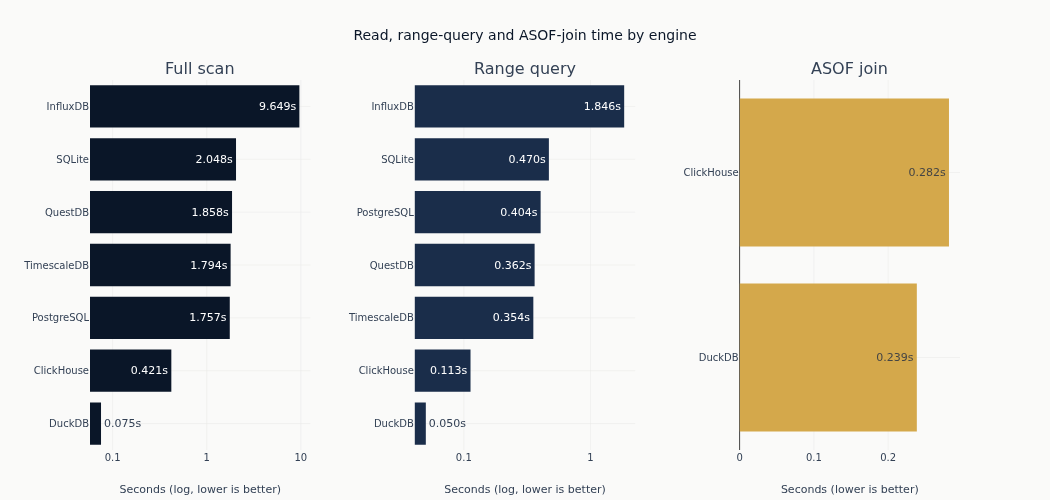

In [50]:
if results:
    _panels = [
        ("read", "Full scan", COLORS["blue"]),
        ("range_query", "Range query", COLORS["slate"]),
        ("asof_join", "ASOF join", COLORS["amber"]),
    ]

    fig = make_subplots(
        rows=1,
        cols=len(_panels),
        subplot_titles=[title for _, title, _ in _panels],
        horizontal_spacing=0.12,
    )

    for col, (op, _title, color) in enumerate(_panels, start=1):
        op_data = results_df.filter(pl.col("operation") == op).sort("time_s")
        if len(op_data) == 0:
            continue
        fig.add_trace(
            go.Bar(
                y=op_data["database"].to_list(),
                x=op_data["time_s"].to_list(),
                orientation="h",
                marker_color=color,
                text=[f"{t:.3f}s" for t in op_data["time_s"].to_list()],
                # "auto" keeps the longest bar's label inside the bar so it does
                # not overrun into the neighbouring panel's y-axis labels; short
                # bars still get an outside label.
                textposition="auto",
                cliponaxis=False,
            ),
            row=1,
            col=col,
        )
        times = op_data["time_s"].to_list()
        spread = max(times) / min(times) if min(times) > 0 else 1.0
        if spread >= LOG_AXIS_RATIO:
            fig.update_xaxes(
                title_text="Seconds (log, lower is better)",
                type="log",
                # One tick per decade. The default labels the minor ticks as well, which
                # on a two-decade axis reads "5 0.1 2 5 1 2" - a 5 to the left of a 0.1.
                dtick=1,
                row=1,
                col=col,
            )
        else:
            fig.update_xaxes(title_text="Seconds (lower is better)", type="linear", row=1, col=col)

    fig.update_layout(
        title_text="Read, range-query and ASOF-join time by engine",
        height=500,
        # Fixed width: the default ~700px crowds eight engines and their value labels.
        width=1050,
        showlegend=False,
        paper_bgcolor=COLORS["bg_light"],
        plot_bgcolor=COLORS["bg_light"],
        # Wider right margin so the 'X.XXXs' value labels don't crop.
        margin=dict(l=90, r=90, t=80, b=50),
    )

    _scale_word = {"S": "Small", "M": "Medium", "L": "Large"}.get(ACTIVE_SCALE, ACTIVE_SCALE)
    print(
        f"Warm reads on a {_scale_word}-scale panel: {total_rows:,} rows, "
        f"{n_sessions} sessions, {len(results_df['database'].unique())} engines. "
        f"Range query covers the first {range_sessions} of {n_sessions} sessions "
        f"({range_share:.1%} of the panel)."
    )
    show_plotly_with_alt(
        fig,
        "Three horizontal-bar panels titled Full scan, Range query and ASOF join. Each "
        "has one bar per database engine, ordered with the slowest at the top and the "
        "fastest at the bottom, and every bar is labelled with its time in seconds. The "
        "full-scan and range-query panels carry every engine that answered; the "
        "ASOF-join panel carries only those with a native ASOF join, so it holds far "
        "fewer bars. Each panel's x-axis is seconds, logarithmic where the engines span "
        "a wide range and linear where they do not, with the axis label saying which.",
    )

In [51]:
if results:
    try:
        fig.write_image(
            OUTPUT_DIR / "server_database_comparison.png", width=1200, height=600, scale=2
        )
    except (RuntimeError, OSError) as exc:
        # Kaleido/Chrome is absent from some benchmark images. Say so rather than
        # passing silently: the book figure is then missing, and a silent skip is
        # indistinguishable from a file that was written.
        print(f"PNG export skipped, the static figure was not written: {exc}")
    save_chart(fig, f"database_comparison_{ACTIVE_SCALE.lower()}")
    save_benchmark_results(results, "databases")

Chart saved: /home/stefan/ml4t/public-teach-a/02_financial_data_universe/.tmp/charts/database_comparison_l.html

📁 Results saved to: /home/stefan/ml4t/public-teach-a/02_financial_data_universe/output/benchmark/databases_l.csv


In [52]:
print("\n### BENCHMARK COVERAGE")
tested = [k for k, v in benchmark_status.items() if v["tested"]]
available = [k for k, v in benchmark_status.items() if v["available"]]
print(f"Tested: {len(tested)}/{len(available)} databases available on this machine")
print(f"Absent: {len(benchmark_status) - len(available)} of {len(benchmark_status)}")
for db in sorted(benchmark_status.keys()):
    entry = benchmark_status[db]
    if entry["tested"]:
        status = "[OK]"
    elif entry["available"]:
        status = "[FAIL]"  # answered the availability check, then did not benchmark
    else:
        status = "absent"  # not reachable here; no result is claimed for it
    print(f"  {status:<8}{db} ({entry['category']})")

print("\n" + "=" * 70)
print("[OK] Database benchmark complete!")
print("=" * 70)


### BENCHMARK COVERAGE
Tested: 7/7 databases available on this machine
Absent: 2 of 9
  absent  ArcticDB (embedded)
  [OK]    ClickHouse (server)
  [OK]    DuckDB (embedded)
  [OK]    InfluxDB (server)
  [OK]    PostgreSQL (server)
  [OK]    QuestDB (server)
  [OK]    SQLite (embedded)
  [OK]    TimescaleDB (server)
  absent  kdb+/PyKX (hft)

[OK] Database benchmark complete!


The fastest engine per operation, read back off the results this run actually
collected. An engine that did not answer cannot appear.

In [53]:
if results:
    fastest = (
        results_df.drop_nulls("time_s")
        .sort("time_s")
        .group_by("operation", maintain_order=True)
        .first()
        .select(["operation", "database", "time_s"])
    )
    print("\nFastest engine per operation (this run):")
    print(fastest)
    print(f"\nEngines benchmarked: {', '.join(sorted(results_df['database'].unique().to_list()))}")


Fastest engine per operation (this run):
shape: (5, 3)
┌─────────────┬──────────┬──────────┐
│ operation   ┆ database ┆ time_s   │
│ ---         ┆ ---      ┆ ---      │
│ str         ┆ str      ┆ f64      │
╞═════════════╪══════════╪══════════╡
│ aggregation ┆ QuestDB  ┆ 0.015005 │
│ range_query ┆ DuckDB   ┆ 0.050125 │
│ read        ┆ DuckDB   ┆ 0.075335 │
│ write       ┆ DuckDB   ┆ 0.172356 │
│ asof_join   ┆ DuckDB   ┆ 0.238528 │
└─────────────┴──────────┴──────────┘

Engines benchmarked: ClickHouse, DuckDB, InfluxDB, PostgreSQL, QuestDB, SQLite, TimescaleDB


## Key Takeaways

No engine is named as fastest here. Which one answered each operation quickest is
printed above, from this run's own results on your hardware, and it can differ from
ours. What carries across runs is the shape of the answer:

1. **Storage layout sets the scan cost.** An engine that stores a column together
   and executes over it in batches reads a minute panel differently from one that
   stores a row together and must touch all nine fields to answer a question about
   two. That division - DuckDB and ClickHouse on one side, SQLite and PostgreSQL
   on the other - is a fact about how the engines are built, and it is the first
   thing to look at in the full-scan panel.
2. **A range query is a different question from a scan**, and it is the one a
   backtest asks. The window above covers the leading sessions of the panel; the
   cell that defines it prints what share of the rows that turned out to be. An
   engine that prunes by time partition or walks a time-ordered index answers it
   without reading the rest, and one that scans and filters does not. Ranking on
   full scans alone would hide the difference. Watch the share: if the window ever
   covers the whole panel, the two left-hand chart panels are measuring one query.
3. **Ingest rate and durability are one number, not two.** Every write time here
   ends when the data is queryable, which is why the engines that acknowledge
   early - QuestDB over ILP, InfluxDB - do not look free.
4. **Every write bar contains a client; three of them let you see how much.**
   PostgreSQL, TimescaleDB and InfluxDB are reached through interfaces that want
   one Python object per row, and building those objects is a separate expression
   that can be timed on its own. The table above the chart gives that time. The
   engines missing from it are not free of client cost - their conversion happens
   inside the call that also does the write, where it cannot be separated - so
   read the table as three lower bounds, not as a division of the field.
5. **The comparison is only as good as its policy.** Every number above is one
   cold write and a warm mean read, for every engine. Warm reads flatter anything
   with a buffer pool; on a cold cache, or across a network, the compressed engines
   gain. Rerun on your own ingestion path before choosing.

**kdb+/PyKX** is skipped unless you supply a q binary and a license, so it is
absent from the numbers above unless you configured it. The chapter discusses
where it fits; this notebook does not claim a result it did not measure.

**Next**: See `20_storage_benchmark_file` for file-format benchmarks (Parquet, Arrow, HDF5).